In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path("..") / "src"))

from data import download_openml_dataset

df, target = download_openml_dataset(6)
df.head()


,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx,class
0,2,4,4,3,2,7,8,2,9,11,7,7,1,8,5,6,Z
1,4,7,5,5,5,5,9,6,4,8,7,9,2,9,7,10,P
2,7,10,8,7,4,8,8,5,10,11,2,8,2,5,5,10,S
3,4,9,5,7,4,7,7,13,1,7,6,8,3,8,0,8,H
4,6,7,8,5,4,7,6,3,7,10,7,9,3,8,3,7,H


In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Target:", target)
print("\nClass counts:")
print(df[target].value_counts())


Shape: (20000, 17)
Columns: ['x-box', 'y-box', 'width', 'high', 'onpix', 'x-bar', 'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege', 'xegvy', 'y-ege', 'yegvx', 'class']
Target: class

Class counts:
class
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64


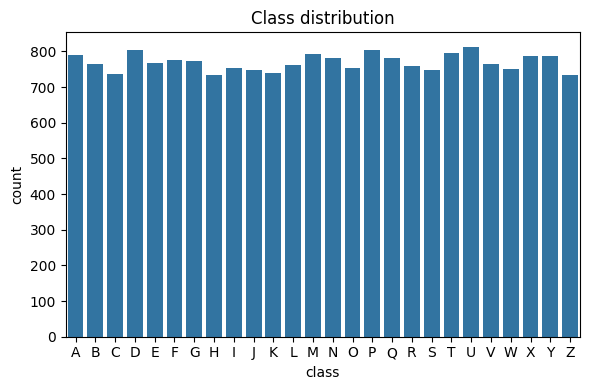

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title("Class distribution")
plt.tight_layout()
plt.show()


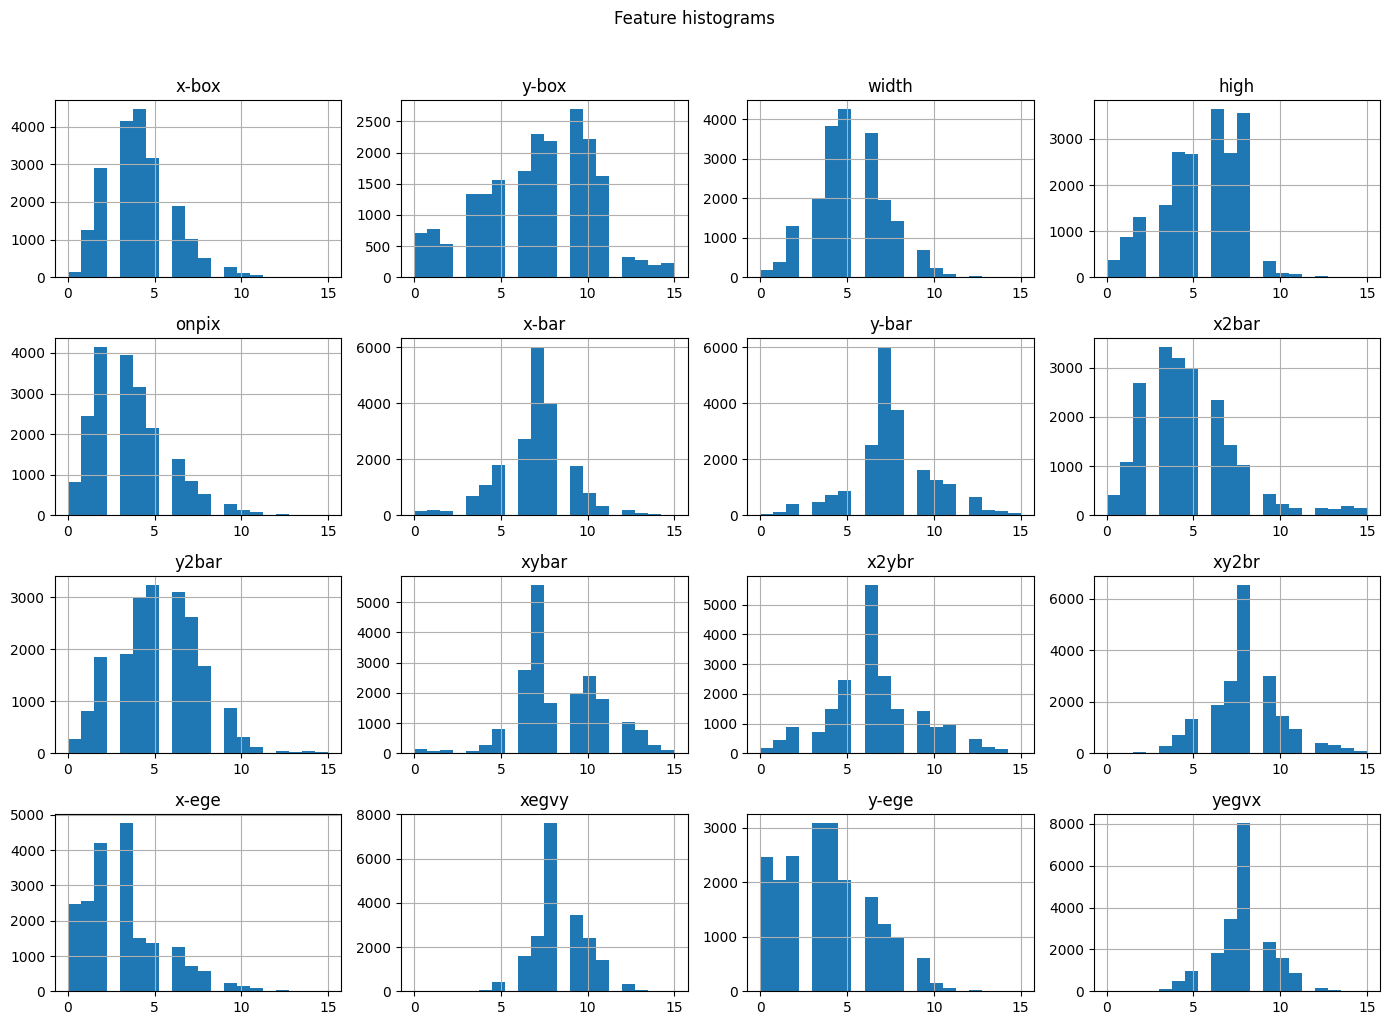

In [5]:
numeric_cols = [c for c in df.columns if c != target]

df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature histograms", y=1.02)
plt.tight_layout()
plt.show()


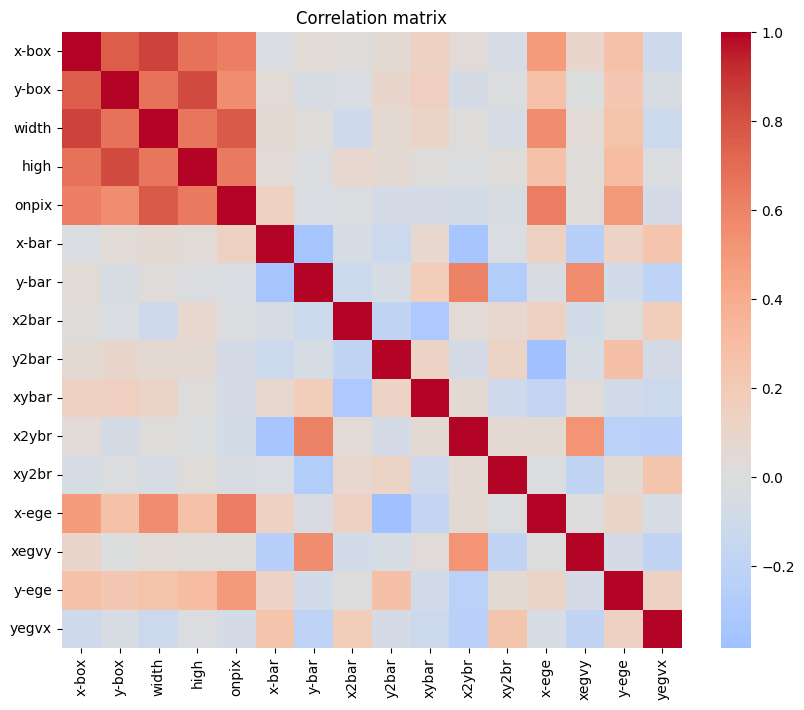

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[numeric_cols].copy()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data


,feature,VIF
0,x-box,32.497363
1,y-box,25.037823
2,width,50.122285
3,high,29.237851
4,onpix,18.778933
5,x-bar,15.991639
6,y-bar,24.337883
7,x2bar,4.907746
8,y2bar,8.579459
9,xybar,15.573648


 ## I’m not removing the high‑VIF features because an MLP doesn’t require independent predictors and handles multicollinearity without issues.

In [8]:
df.isna().sum()


x-box    0
y-box    0
width    0
high     0
onpix    0
x-bar    0
y-bar    0
x2bar    0
y2bar    0
xybar    0
x2ybr    0
xy2br    0
x-ege    0
xegvy    0
y-ege    0
yegvx    0
class    0
dtype: int64

## We dont have any missing values, so inputing is not needed


In [9]:
df.duplicated().sum()


np.int64(1332)

## We have many duplicates so i decide to drop them

In [10]:
df_clean = df.drop_duplicates().reset_index(drop=True)
df_clean.shape


(18668, 17)

In [11]:
skew = df_clean[numeric_cols].skew()
kurt = df_clean[numeric_cols].kurt()

pd.DataFrame({"skew": skew, "kurtosis": kurt})


,skew,kurtosis
x-box,0.760673,0.959944
y-box,-0.211625,-0.335004
width,0.341253,0.331962
high,-0.250757,-0.153199
onpix,0.964361,1.237194
x-bar,-0.257365,1.308435
y-bar,0.101336,0.838532
x2bar,1.118679,2.037881
y2bar,0.198646,0.069933
xybar,0.134059,0.137426


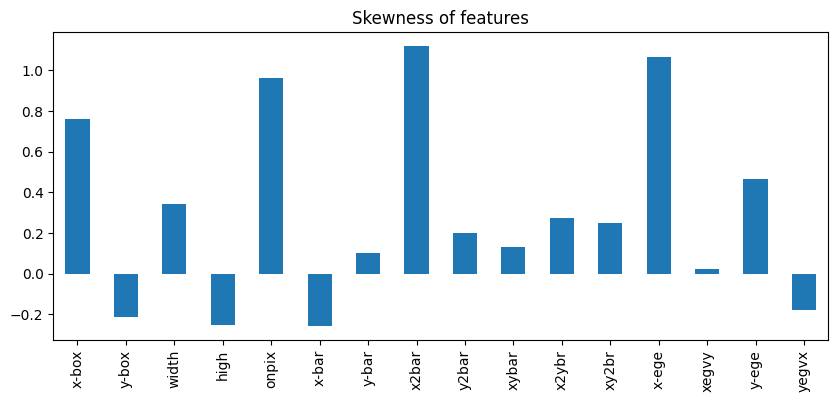

In [12]:
plt.figure(figsize=(10,4))
skew.plot(kind="bar", title="Skewness of features")
plt.show()


## The distributions show acceptable levels of skewness and kurtosis, so I proceed with StandardScaler as the normalization method

## EDA Summary  
The Letter Recognition dataset (OpenML ID 6) was cleaned by removing 1332 duplicate records. No missing values were found. Feature distributions are approximately normal (skew < 1.2, kurtosis < 3), so StandardScaler is appropriate. Correlation analysis and VIF showed  multicollinearity, but for neural network i decide to not delete any features.
